In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches

nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
class PrivacyPolicyRuleExtractor(BaseEstimator, TransformerMixin):
    """Extract rule-based features aligned with privacy policy dimensions"""
    def __init__(self):
        self.feature_names = []

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            if 'policy_text' in X.columns:
                texts = X['policy_text'].values
            else:
                texts = X.iloc[:, 0].values
        else:
            texts = X

        features_list = []

        for policy in texts:
            features = {}

            # Basic text statistics
            policy_str = str(policy)
            features['policy_length'] = len(policy_str)
            features['word_count'] = len(policy_str.split())

            sentences = re.split(r'[.!?]+', policy_str)
            sentences = [s for s in sentences if s.strip()]
            features['sentence_count'] = len(sentences)

            if features['sentence_count'] > 0:
                features['avg_sentence_length'] = features['word_count'] / features['sentence_count']
            else:
                features['avg_sentence_length'] = 0

            # 1. Transparency features
            features.update(self._extract_transparency_features(policy_str, sentences))

            # 2. Data Collection features
            features.update(self._extract_data_collection_features(policy_str))

            # 3. User Control features
            features.update(self._extract_user_control_features(policy_str))

            # 4. Security features
            features.update(self._extract_security_features(policy_str))

            # 5. Regulatory Compliance features
            features.update(self._extract_regulatory_features(policy_str))

            features_list.append(features)

        features_df = pd.DataFrame(features_list)

        self.feature_names = features_df.columns.tolist()

        return features_df

    def get_feature_names_out(self):
        return self.feature_names

    def _extract_transparency_features(self, text, sentences):
        """Extract features related to transparency dimensions with expanded terminology"""
        text = text.lower()
        features = {}

        features['sentence_count'] = len(sentences)

        if len(sentences) > 0:
            avg_sent_len = sum([len(s.split()) for s in sentences]) / len(sentences)
        else:
            avg_sent_len = 0

        features['readability_score'] = 206.835 - (1.015 * avg_sent_len)  # Flesch Reading score

        # Technical term density features
        technical_terms = [
            'algorithm', 'analytics', 'api', 'authentication', 'cache', 'cookies',
            'encryption', 'gdpr', 'hash', 'hipaa', 'https', 'oauth', 'sdk', 'ssl', 'tls',
            'data subject', 'processor', 'controller', 'jurisdiction', 'pseudonymization',
            'anonymization', 'aggregation', 'tokenization', 'metadata', 'cookies',
            'encryption', 'decryption', 'cryptographic', 'hashing', 'ssl/tls',
            'two-factor', 'multi-factor', 'authentication', 'api', 'interface',
            'third-party', 'third party', '3rd party', 'third-parties', 'third parties',
            'data subject', 'data controller', 'data processor', 'data protection',
            'data security', 'data processing', 'data collection', 'data retention'
        ]
        technical_terms = list(set(technical_terms))
        tech_term_count = sum([len(re.findall(r'\b' + re.escape(term) + r'\b', text)) for term in technical_terms])
        features['technical_term_count'] = tech_term_count
        features['technical_term_density'] = tech_term_count / max(len(text.split()), 1) * 1000

        # Vagueness features
        vague_terms = [
            'may', 'might', 'could', 'possibly', 'potentially', 'from time to time',
            'occasionally', 'sometimes', 'periodically', 'certain', 'various', 'some',
            'appropriate', 'reasonable', 'generally', 'typically', 'usually',
            'may include', 'may contain', 'may collect', 'may use', 'may share',
            'may provide', 'may process', 'may disclose', 'may transfer', 'may receive'
        ]
        vague_terms = list(set(vague_terms))
        vague_count = sum([len(re.findall(r'\b' + re.escape(term) + r'\b', text)) for term in vague_terms])
        features['vague_term_count'] = vague_count
        features['vagueness_density'] = vague_count / max(len(text.split()), 1) * 1000

        # Additional clarity features
        features['has_definitions'] = 1 if re.search(r'definition|terms? (used|defined)|what.{1,15}mean[s]?|glossary', text) else 0
        features['has_examples'] = len(re.findall(r'(for example|such as|e\.g\.|i\.e\.|including|for instance)', text)) / 10
        features['has_summary'] = 1 if re.search(r'summary|overview|brief|key (points|information)', text) else 0
        features['has_headings'] = 1 if re.search(r'\n[A-Z][\w\s]+[:;]', text) else 0
        features['has_bullet_points'] = 1 if re.search(r'(•|\*|\-|\d+\.)\s+\w+', text) else 0

        # Reading level indicators
        features['long_word_ratio'] = len([w for w in text.split() if len(w) > 6]) / max(len(text.split()), 1)
        features['avg_sentence_len'] = avg_sent_len
        features['long_sent_count'] = len([s for s in sentences if len(s.split()) > 25])
        features['long_sent_ratio'] = features['long_sent_count'] / max(features['sentence_count'], 1)

        return features

    def _extract_data_collection_features(self, text):
        """Extract features related to data collection dimensions"""
        text = str(text).lower()
        features = {}

        # Data types mentioned
        data_types = [
            'name', 'email', 'address', 'phone', 'location', 'gps', 'ip address',
            'device id', 'mac address', 'cookies', 'heart rate', 'steps', 'calories',
            'weight', 'height', 'workout data', 'sleep data', 'health data', 'biometric',
            'fitness', 'activity', 'usage', 'browser', 'medical', 'demographic',
            'personal information', 'personal data', 'contact information',
            'identifiable information', 'personally identifiable', 'pii',
            'social security', 'ssn', 'driver\'s license', 'passport', 'id number',
            'financial information', 'payment information', 'credit card',
            'debit card', 'bank account', 'payment details', 'financial data',
            'health information', 'medical information', 'medical history',
            'biometric data', 'fingerprint', 'facial recognition', 'voice print',
            'retina scan', 'dna', 'genetic data', 'genetic information',
            'browsing history', 'search history', 'usage data', 'usage information',
            'device information', 'hardware information', 'ip address', 'mac address',
            'device id', 'advertising id', 'unique identifier', 'unique id',
            'location data', 'gps data', 'geolocation', 'location information',
            'demographic information', 'demographic data', 'age', 'gender', 'sex',
            'income', 'education', 'occupation', 'employment', 'marital status',
            'family status', 'ethnicity', 'race', 'nationality', 'country of origin',
            'religion', 'political affiliation', 'sexual orientation',
            'cookies', 'web beacons', 'pixels', 'tracking technologies', 'web beacons',
            'pixel tags', 'clear gifs', 'web bugs', 'tracking pixels',
            'user preferences', 'preferences', 'settings', 'configuration',
            'profile information', 'profile data', 'account information'
        ]
        data_types = list(set(data_types))
        type_count = sum([1 if re.search(r'\b' + re.escape(term) + r'\b', text) else 0 for term in data_types])
        features['data_types_mentioned'] = type_count
        features['data_types_coverage'] = type_count / len(data_types)
        features['data_types_density'] = type_count / max(features.get('word_count', 1), 1) * 1000

        # Purpose clarity
        purpose_terms = [
            'purpose', 'in order to', 'so that', 'to provide', 'to improve',
            'to personalize', 'to analyze', 'to research', 'to develop', 'to market',
            'to communicate', 'to protect', 'to comply', 'to process', 'to fulfill',
            'to customize', 'to tailor', 'to enhance', 'to optimize', 'to personalize',
            'to deliver', 'to send', 'to contact', 'to notify', 'to inform',
            'to respond', 'to answer', 'to reply', 'to address', 'to resolve',
            'to complete', 'to process', 'to verify', 'to validate', 'to confirm',
            'to fulfill', 'to satisfy', 'to meet', 'to comply with', 'to adhere to',
            'to protect', 'to secure', 'to safeguard', 'to prevent', 'to detect',
            'to investigate', 'to enforce', 'to implement', 'to maintain',
            'to analyze', 'to study', 'to research', 'to evaluate', 'to assess',
            'to measure', 'to monitor', 'to track', 'to understand', 'to learn',
            'to improve', 'to enhance', 'to develop', 'to upgrade', 'to update',
            'to manage', 'to administer', 'to operate', 'to run', 'to maintain',
            'to market', 'to advertise', 'to promote', 'to offer', 'to recommend'
        ]
        purpose_terms = list(set(purpose_terms))
        purpose_count = sum([len(re.findall(r'\b' + re.escape(term) + r'\b', text)) for term in purpose_terms])
        features['purpose_term_count'] = purpose_count
        features['purpose_clarity_score'] = purpose_count / max(features.get('word_count', 1), 1) * 1000

        # Data collection section
        features['has_data_collection_section'] = 1 if re.search(r'(information|data).{1,20}(we|us|our).{1,20}(collect|gather|obtain|receive|acquire|process)', text) else 0
        features['has_purpose_section'] = 1 if re.search(r'(how|why|what).{1,20}(we|us|our).{1,20}(use|process|do with)', text) else 0
        features['has_sharing_section'] = 1 if re.search(r'(share|disclos|provide|transfer).{1,20}(information|data)', text) else 0
        features['has_retention_section'] = 1 if re.search(r'(retain|store|keep|maintain).{1,20}(information|data)', text) else 0

        # Data collection practices
        features['mentions_data_categories'] = 1 if re.search(r'(categories|types).{1,10}(of|about).{1,10}(information|data)', text) else 0
        features['mentions_data_sources'] = 1 if re.search(r'(sources|collect|obtain|receive).{1,20}(information|data)', text) else 0
        features['mentions_collection_methods'] = 1 if re.search(r'(how|ways|means|methods).{1,20}(collect|gather|obtain)', text) else 0

        return features

    def _extract_user_control_features(self, text):
        """Extract features related to user control dimensions"""
        text = str(text).lower()
        features = {}

        # Control options
        control_options = [
            'opt-out', 'opt out', 'unsubscribe', 'delete account', 'delete your data',
            'access your data', 'modify your data', 'edit your information',
            'privacy settings', 'account settings', 'preferences', 'withdraw consent',
            'right to access', 'right to delete', 'right to correct', 'right to object',
            'right to restrict', 'data portability', 'right to withdraw',
            'opt-in', 'opt in', 'opt out', 'opt-out', 'unsubscribe', 'stop receiving',
            'manage preferences', 'update preferences', 'change preferences',
            'modify preferences', 'control your data', 'control your information',
            'manage your data', 'manage your information', 'manage your account',
            'modify your data', 'modify your information', 'modify your account',
            'edit your data', 'edit your information', 'edit your account',
            'update your data', 'update your information', 'update your account',
            'delete your data', 'delete your information', 'delete your account',
            'remove your data', 'remove your information', 'remove your account',
            'erase your data', 'erase your information', 'erase your account',
            'right to access', 'right to know', 'right to be informed',
            'right to rectification', 'right to correct', 'right to update',
            'right to erasure', 'right to be forgotten', 'right to delete',
            'right to restriction', 'right to restrict', 'right to object',
            'right to data portability', 'data portability right',
            'right to withdraw consent', 'withdraw your consent', 'revoke consent',
            'right to lodge a complaint', 'right to complain',
            'privacy controls', 'privacy settings', 'privacy preferences',
            'account settings', 'account preferences', 'account controls',
            'user settings', 'user preferences', 'user controls'
        ]
        control_options = list(set(control_options))
        control_count = sum([1 if re.search(r'\b' + re.escape(term) + r'\b', text) else 0 for term in control_options])
        features['control_options_count'] = control_count
        features['control_options_coverage'] = control_count / len(control_options)
        features['control_options_density'] = control_count / max(features.get('word_count', 1), 1) * 1000

        # Access barriers
        barrier_terms = [
            'fee', 'charge', 'cost', 'payment', 'reasonable', 'may deny',
            'may decline', 'discretion', 'reserves the right', 'limitation',
            'subject to', 'certain restrictions', 'within a reasonable time',
            'valid request', 'verification required',
            'fee', 'fees', 'charge', 'charges', 'cost', 'costs', 'payment', 'payments',
            'pay', 'paid', 'charge', 'charged', 'fee-based', 'fee based',
            'administrative fee', 'processing fee', 'service fee', 'handling fee',
            'may deny', 'may refuse', 'may reject', 'may decline', 'may not process',
            'reserve the right to deny', 'reserve the right to refuse',
            'reserve the right to reject', 'reserve the right to decline',
            'right to deny', 'right to refuse', 'right to reject', 'right to decline',
            'may limit', 'may restrict', 'may constrain', 'may reduce',
            'limit', 'limits', 'limited', 'limitation', 'limitations',
            'restrict', 'restricts', 'restricted', 'restriction', 'restrictions',
            'constrain', 'constrains', 'constrained', 'constraint', 'constraints',
            'discretion', 'discretionary', 'sole discretion', 'absolute discretion',
            'our discretion', 'our sole discretion', 'our absolute discretion',
            'subject to', 'subject to our', 'subject to approval',
            'may require', 'require', 'requires', 'required', 'requirement',
            'verify', 'verifies', 'verified', 'verification', 'verify your identity',
            'identity verification', 'identity confirmation', 'confirm your identity',
            'prove your identity', 'proof of identity', 'identification',
            'reasonable time', 'reasonable period', 'reasonable timeframe',
            'within a reasonable', 'may take time', 'may take some time',
            'excessive', 'manifestly unfounded', 'unfounded', 'unreasonable',
            'administrative burden', 'undue burden', 'unduly burdensome'
        ]
        barrier_count = sum([1 if re.search(r'\b' + re.escape(term) + r'\b', text) else 0 for term in barrier_terms])
        features['access_barrier_count'] = barrier_count
        features['access_barrier_density'] = barrier_count / max(features.get('word_count', 1), 1) * 1000

        # Instructions clarity
        features['has_control_instructions'] = 1 if re.search(r'(how|steps|instructions|process|procedure).{0,20}(to|for).{0,20}(opt|delete|access|modify|update|edit|change|request|exercise)', text) else 0
        features['has_contact_for_privacy'] = 1 if re.search(r'(contact|email|call|write to|reach).{0,30}(privacy|data|information|questions|concerns|rights)', text) else 0
        features['has_contact_info'] = 1 if re.search(r'(email|phone|address|contact form|contact us).{0,30}(privacy|data protection|questions|concerns|inquiries)', text) else 0
        features['has_time_frame'] = 1 if re.search(r'(within|in).{1,5}(\d+|one|two|three|four|five|six|seven|eight|nine|ten).{1,5}(days|weeks|months|business days)', text) else 0

        return features

    def _extract_security_features(self, text):
        """Extract features related to security dimensions"""
        text = str(text).lower()
        features = {}

        # Security details
        security_terms = [
            'encrypt', 'ssl', 'tls', 'https', 'secure connection', 'security protocol',
            'firewalls?', 'authentication', 'password', 'two[- ]factor', 'multi[- ]factor',
            'security standards?', 'security (practices|measures)', 'safeguards?',
            'protected', 'security team', 'security audit', 'security review',
            'encryption', 'encrypted', 'encrypt', 'encrypts', 'encrypting',
            'ssl', 'tls', 'https', 'secure socket layer', 'transport layer security',
            'secure connection', 'secure transmission', 'secure transfer', 'secure channel',
            'security protocol', 'security measure', 'security practice', 'security procedure',
            'firewall', 'firewalls', 'firewall protection', 'firewall security',
            'authentication', 'authenticate', 'authenticates', 'authenticated',
            'password', 'passwords', 'password protection', 'password protected',
            'strong password', 'secure password', 'password policy',
            'two factor', 'two-factor', 'two factor authentication', 'two-factor authentication',
            'multi factor', 'multi-factor', 'multi factor authentication', 'multi-factor authentication',
            '2fa', 'mfa', 'second factor', '2-step verification', 'two-step verification',
            'security standard', 'security standards', 'security protocol', 'security protocols',
            'security practice', 'security practices', 'security procedure', 'security procedures',
            'security measure', 'security measures', 'security control', 'security controls',
            'security safeguard', 'security safeguards', 'safeguard', 'safeguards',
            'protected', 'protection', 'protect', 'protects', 'protecting',
            'security team', 'security personnel', 'security staff', 'security professionals',
            'security audit', 'security assessment', 'security review', 'security evaluation',
            'vulnerability test', 'vulnerability assessment', 'vulnerability scan',
            'penetration test', 'penetration testing', 'pen test', 'pen testing',
            'security testing', 'security monitoring', 'security surveillance',
            'intrusion detection', 'intrusion prevention', 'ids', 'ips',
            'secure socket', 'secure sockets', 'secure layer', 'secure protocol',
            'data protection', 'information protection', 'data security', 'information security',
            'cybersecurity', 'cyber security', 'cyber-security', 'network security'
        ]
        security_terms = list(set(security_terms))
        security_count = sum([1 if re.search(r'\b' + term + r'\b', text) else 0 for term in security_terms])
        features['security_detail_count'] = security_count
        features['security_detail_coverage'] = security_count / len(security_terms)
        features['security_detail_density'] = security_count / max(features.get('word_count', 1), 1) * 1000

        # Breach notification
        breach_terms = [
            'breach', 'incident', 'unauthorized access', 'compromise', 'security event',
            'notify', 'inform', 'alert', 'security breach', 'data breach',
            'breach notification', 'security incident response',
            'breach', 'breached', 'breaches', 'data breach', 'security breach',
            'privacy breach', 'information breach', 'breach of security',
            'incident', 'incidents', 'security incident', 'privacy incident',
            'data incident', 'information incident', 'security event',
            'unauthorized access', 'unauthorized disclosure', 'unauthorized acquisition',
            'unauthorized use', 'unauthorized release', 'unauthorized exposure',
            'compromise', 'compromised', 'compromise of data', 'compromise of information',
            'data compromise', 'information compromise', 'security compromise',
            'notify', 'notifies', 'notified', 'notification', 'notifications',
            'inform', 'informs', 'informed', 'informing', 'information',
            'alert', 'alerts', 'alerted', 'alerting', 'alert you',
            'notify you', 'inform you', 'alert customers', 'inform customers',
            'notify customers', 'breach notification', 'incident notification',
            'security notification', 'data breach notification', 'breach notice',
            'security incident response', 'incident response', 'breach response',
            'security response', 'data breach response', 'incident response plan',
            'security incident response plan', 'breach response plan',
            'data breach response plan', 'incident response procedure',
            'security incident procedure', 'breach procedure',
            'data breach procedure', 'security breach procedure',
            'notify without delay', 'notify promptly', 'notify immediately',
            'inform without delay', 'inform promptly', 'inform immediately',
            'alert without delay', 'alert promptly', 'alert immediately'
        ]
        breach_terms = list(set(breach_terms))
        breach_count = sum([1 if re.search(r'\b' + re.escape(term) + r'\b', text) else 0 for term in breach_terms])
        features['breach_notification_count'] = breach_count
        features['has_breach_notification'] = 1 if breach_count > 0 else 0
        features['breach_notification_density'] = breach_count / max(features.get('word_count', 1), 1) * 1000

        # Data protection additional features
        features['has_retention_policy'] = 1 if re.search(r'(retain|keep|store|hold|maintain).{0,30}(for|until|period|duration|time)', text) else 0
        features['mentions_encryption'] = 1 if re.search(r'encrypt', text) else 0
        features['mentions_secure_transmission'] = 1 if re.search(r'(secure|encrypted|protected).{0,15}(transmission|transfer|communication)', text) else 0
        features['mentions_security_measures'] = 1 if re.search(r'(security|protective|safeguard).{0,15}(measures|controls|safeguards|procedures|practices)', text) else 0
        features['mentions_security_standards'] = 1 if re.search(r'(security|industry).{0,15}(standards?|practices|protocols|guidelines)', text) else 0
        features['mentions_security_monitoring'] = 1 if re.search(r'(security|monitor|surveillance).{0,15}(monitoring|detection|prevention)', text) else 0

        return features

    def _extract_regulatory_features(self, text):
        """Extract features related to regulatory compliance dimensions"""
        text = str(text).lower()
        features = {}

        # Regulatory coverage
        regulations = [
            'gdpr', 'ccpa', 'cpra', 'lgpd', 'pipeda', 'privacy shield',
            'hipaa', 'coppa', 'ferpa', 'glba', 'shield', 'california privacy',
            'nevada privacy', 'virginia privacy', 'maine privacy', 'new york privacy',
            'data protection law', 'data protection regulation',
            'gdpr', 'general data protection regulation', 'eu data protection',
            'ccpa', 'california consumer privacy act', 'california privacy',
            'cpra', 'california privacy rights act', 'cppa', 'california privacy protection agency',
            'lgpd', 'lei geral de proteção de dados', 'brazilian data protection',
            'pipeda', 'personal information protection', 'electronic documents act',
            'privacy shield', 'eu-us privacy shield', 'privacy shield framework',
            'swiss-us privacy shield', 'swiss privacy shield',
            'hipaa', 'health insurance portability', 'health insurance accountability',
            'hitech', 'health information technology',
            'coppa', 'children\'s online privacy', 'children\'s privacy',
            'ferpa', 'family educational rights', 'family education rights',
            'glba', 'gramm-leach-bliley', 'gramm leach bliley', 'financial modernization act',
            'fcra', 'fair credit reporting act', 'fcra',
            'data protection directive', 'eu directive', 'eu regulation',
            'california privacy', 'california consumer', 'california residents',
            'nevada privacy', 'nevada residents', 'nevada consumers',
            'virginia privacy', 'virginia consumer', 'virginia residents',
            'maine privacy', 'maine consumer', 'maine residents',
            'new york privacy', 'new york consumer', 'new york residents',
            'colorado privacy', 'colorado consumer', 'colorado residents',
            'utah privacy', 'utah consumer', 'utah residents',
            'connecticut privacy', 'connecticut consumer', 'connecticut residents',
            'state privacy law', 'state privacy laws', 'state data protection',
            'data protection law', 'data protection regulation', 'data protection act',
            'privacy law', 'privacy regulation', 'privacy act', 'privacy framework',
            'data protection authority', 'supervisory authority',
            'gdpr compliant', 'ccpa compliant', 'hipaa compliant',
            'privacy shield certified', 'privacy shield compliant'
        ]
        regulations = list(set(regulations))
        reg_count = sum([1 if re.search(r'\b' + re.escape(term) + r'\b', text) else 0 for term in regulations])
        features['regulatory_mention_count'] = reg_count
        features['regulatory_coverage_score'] = reg_count / len(regulations)
        features['regulatory_density'] = reg_count / max(features.get('word_count', 1), 1) * 1000

        # Rights clarity
        rights_terms = [
            'right to access', 'right to delete', 'right to correct', 'right to object',
            'right to restrict', 'right to data portability', 'right to withdraw',
            'consumer rights', 'privacy rights', 'data subject rights',
            'legal rights', 'statutory rights',
            'right to access', 'right of access', 'access right', 'right to access your data',
            'right to know', 'right to be informed', 'right to information',
            'right to deletion', 'right to delete', 'right to be deleted',
            'right to erasure', 'right to be forgotten', 'erasure right',
            'right to correct', 'right to rectification', 'right to update',
            'right to object', 'right to objection', 'objection right',
            'right to restrict', 'right to restriction', 'restriction right',
            'right to data portability', 'data portability right', 'right to port',
            'right to withdraw consent', 'right to withdraw', 'withdrawal right',
            'right to opt-out', 'right to opt out', 'opt-out right', 'opt out right',
            'right to opt-in', 'right to opt in', 'opt-in right', 'opt in right',
            'right to lodge a complaint', 'right to complain', 'complaint right',
            'consumer rights', 'consumer privacy rights', 'privacy rights',
            'data subject rights', 'data protection rights', 'information rights',
            'legal rights', 'statutory rights', 'gdpr rights',
            'ccpa rights', 'california rights', 'california consumer rights',
            'virginia rights', 'virginia consumer rights',
            'colorado rights', 'colorado consumer rights',
            'connecticut rights', 'connecticut consumer rights',
            'utah rights', 'utah consumer rights',
            'your rights', 'your privacy rights', 'your data rights',
            'rights under', 'rights under gdpr', 'rights under ccpa',
            'rights under the law', 'rights under applicable law',
            'right to access your data', 'right to access your information',
            'right to access your personal data',  'right to access your data', 'right to access your information',
            'right to access your personal data', 'right to access your personal information'
        ]
        rights_terms = list(set(rights_terms))
        rights_count = sum([1 if re.search(re.escape(term), text) else 0 for term in rights_terms])
        features['rights_mention_count'] = rights_count
        features['rights_clarity_score'] = rights_count / len(rights_terms)
        features['rights_density'] = rights_count / max(features.get('word_count', 1), 1) * 1000

        # Additional regulatory features
        features['mentions_legal_basis'] = 1 if re.search(r'legal basis|lawful basis|legitimate interest', text) else 0
        features['mentions_dpo'] = 1 if re.search(r'data protection officer|dpo|privacy officer|privacy team|privacy staff', text) else 0
        features['mentions_international_transfer'] = 1 if re.search(r'(international|cross.border|transfer|outside).{1,30}(country|jurisdiction|region|territory)', text) else 0
        features['mentions_age_restrictions'] = 1 if re.search(r'(age|child|children|minor|under).{1,10}(\d+|thirteen|sixteen|eighteen)', text) else 0
        features['mentions_consent'] = 1 if re.search(r'consent|permission|authorize|approval|agree|accept', text) else 0
        features['mentions_jurisdiction'] = 1 if re.search(r'jurisdiction|governing law|applicable law|law applies|laws of|courts of', text) else 0
        features['mentions_accountability'] = 1 if re.search(r'accountability|responsible|responsibility|comply|compliance|adhere', text) else 0

        return features

In [ ]:
def extract_embeddings(texts, model_name='distilbert-base-uncased'):
    """Extract embeddings from pre-trained transformer model"""
    #tokenizer and model
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)

    batch_size = 2
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:min(i+batch_size, len(texts))]

        # Tokenize
        encoded_input = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors='pt'
        )

        # Get embeddings
        with torch.no_grad():
            outputs = model(**encoded_input)

        embeddings = outputs.last_hidden_state[:, 0, :].numpy()
        all_embeddings.append(embeddings)

    all_embeddings = np.vstack(all_embeddings)

    # Reduce dimensions (as the dataset is small)
    n_components = min(5, len(texts) - 1)
    pca = PCA(n_components=n_components)
    reduced_embeddings = pca.fit_transform(all_embeddings)

    embeddings_df = pd.DataFrame(
        reduced_embeddings,
        columns=[f'emb_{i}' for i in range(reduced_embeddings.shape[1])]
    )

    return embeddings_df

In [ ]:
def train_and_evaluate_model(train_df, test_df, dimension_cols):
    """Train on training set and evaluate on test set for each dimension"""

    dimension_cols = [col for col in dimension_cols if not col.startswith('visual_presentation')]

    # rule-based features
    print("Extracting rule-based features...")
    rule_extractor = PrivacyPolicyRuleExtractor()
    train_rule_features = rule_extractor.fit_transform(train_df[['policy_text']])
    test_rule_features = rule_extractor.transform(test_df[['policy_text']])

    #  embeddings
    print("Extracting embeddings...")
    train_embeddings = extract_embeddings(train_df['policy_text'].tolist())
    test_embeddings = extract_embeddings(test_df['policy_text'].tolist())

    X_train = pd.concat([train_rule_features, train_embeddings], axis=1)
    X_test = pd.concat([test_rule_features, test_embeddings], axis=1)

    for col in X_train.columns:
        if col not in X_test.columns:
            X_test[col] = 0

    X_test = X_test[X_train.columns]

    print(f"Created feature matrices with {X_train.shape[1]} features")

    results = {
        'dimension': [],
        'mae': [],      # Mean Absolute Error
        'accuracy': [], # Accuracy (predictions within 1 unit of actual)
        'feature_importance': []
    }

    models = {}

    for col in dimension_cols:
        print(f"\nTraining model for: {col}")

        if col not in train_df.columns or col not in test_df.columns:
            print(f"Column {col} not found in dataset. Skipping.")
            continue

        y_train = train_df[col].values
        y_test = test_df[col].values

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model = ElasticNet(alpha=0.5, l1_ratio=0.7, max_iter=10000, random_state=42)
        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)

        mae = mean_absolute_error(y_test, y_pred)

        accuracy = np.mean(np.abs(y_test - y_pred) <= 1.0)

        importance = pd.Series(np.abs(model.coef_), index=X_train.columns)
        top_features = importance.sort_values(ascending=False).head(10)

        print(f"MAE: {mae:.4f}, Accuracy (within 1 unit): {accuracy:.4f}")
        print("Top 5 important features:")
        for feat, imp in top_features.head(5).items():
            print(f"  {feat}: {imp:.4f}")

        results['dimension'].append(col)
        results['mae'].append(mae)
        results['accuracy'].append(accuracy)
        results['feature_importance'].append(top_features)
        models[col] = model

    results_df = pd.DataFrame({
        'dimension': results['dimension'],
        'mae': results['mae'],
        'accuracy': results['accuracy']
    })

    return results_df, results['feature_importance'], models, X_train.columns, rule_extractor

In [ ]:
def visualize_results(results_df):
    """Visualize model performance metrics"""
    plt.figure(figsize=(15, 8))

    # Plot MAE
    plt.subplot(2, 1, 1)
    ax = sns.barplot(x='dimension', y='mae', data=results_df)
    plt.title('Model Performance (MAE) by Dimension', fontsize=14)
    plt.xlabel('Dimension', fontsize=12)
    plt.ylabel('Mean Absolute Error', fontsize=12)
    plt.xticks(rotation=45, ha='right')

    for i, v in enumerate(results_df['mae']):
        ax.text(i, v + 0.02, f"{v:.2f}", ha='center')

    # Plot Accuracy
    plt.subplot(2, 1, 2)
    ax = sns.barplot(x='dimension', y='accuracy', data=results_df)
    plt.title('Model Performance (Accuracy within 1 unit) by Dimension', fontsize=14)
    plt.xlabel('Dimension', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.xticks(rotation=45, ha='right')

    for i, v in enumerate(results_df['accuracy']):
        ax.text(i, v + 0.02, f"{v:.2f}", ha='center')

    plt.tight_layout()
    plt.show()

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

def create_simple_performance_chart(dimension, mae, accuracy):
    """Create a simple performance chart with MAE and accuracy"""

    fig, ax1 = plt.subplots(figsize=(14, 8))

    sorted_indices = np.argsort(mae)
    sorted_dim = [dimension[i] for i in sorted_indices]
    sorted_mae = [mae[i] for i in sorted_indices]
    sorted_acc = [accuracy[i] for i in sorted_indices]

    x = np.arange(len(sorted_dim))
    colors = plt.cm.viridis(np.linspace(0, 0.8, len(sorted_dim)))
    bars = ax1.bar(x, sorted_mae, color=colors, alpha=0.7)

    ax1.set_xlabel('Dimension', fontsize=12)
    ax1.set_ylabel('Mean Absolute Error (lower is better)', fontsize=12, color='blue')
    ax1.set_xticks(x)
    ax1.set_xticklabels(sorted_dim, rotation=45, ha='right')
    ax1.tick_params(axis='y', labelcolor='blue')

    ax2 = ax1.twinx()
    ax2.plot(x, sorted_acc, 'ro-', linewidth=2, markersize=8)
    ax2.set_ylabel('Accuracy (within 1 unit)', fontsize=12, color='red')
    ax2.set_ylim(0, 1.1)
    ax2.tick_params(axis='y', labelcolor='red')

    for i, acc in enumerate(sorted_acc):
        ax2.text(i, acc + 0.05, f"{acc:.0%}", ha='center', va='bottom', color='red')

    plt.title('Privacy Policy Evaluation Model Performance', fontsize=16)

    from matplotlib.lines import Line2D
    custom_lines = [
        Line2D([0], [0], color='blue', lw=4, alpha=0.7),
        Line2D([0], [0], color='red', lw=2, marker='o', markersize=8)
    ]
    ax1.legend(custom_lines, ['MAE (lower is better)', 'Accuracy (higher is better)'],
              loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

    plt.tight_layout()
    return fig

def create_radar_chart(dimension, accuracy):
    """Create a radar chart of accuracy by dimension"""

    categories = {
        'Transparency': [dim for dim in dimension if 'transparency' in dim],
        'Data Collection': [dim for dim in dimension if 'data_collection' in dim],
        'User Control': [dim for dim in dimension if 'user_control' in dim],
        'Security': [dim for dim in dimension if 'security' in dim],
        'Regulatory': [dim for dim in dimension if 'regulatory' in dim]
    }


    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, polar=True)

    angles = np.linspace(0, 2*np.pi, len(dimension), endpoint=False).tolist()

    angles += [angles[0]]
    values = accuracy + [accuracy[0]]

    ax.plot(angles, values, 'o-', linewidth=2)
    ax.fill(angles, values, alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([dim.split('_')[-2:] for dim in dimension], fontsize=10)

    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['25%', '50%', '75%', '100%'])

    plt.title('Accuracy by Dimension (within 1 unit)', fontsize=16, y=1.1)

    plt.tight_layout()
    return fig

def create_normalized_mae_chart(dimension, mae):
    """Create a normalized MAE chart (percentage of scale)"""
    # 5-point scale
    scale_range = 4  # (5-1)


    nmae = [m / scale_range for m in mae]


    sorted_indices = np.argsort(nmae)
    sorted_dim = [dimension[i] for i in sorted_indices]
    sorted_nmae = [nmae[i] for i in sorted_indices]


    fig, ax = plt.subplots(figsize=(12, 8))


    colors = plt.cm.viridis(np.linspace(0, 0.8, len(sorted_dim)))


    bars = ax.bar(range(len(sorted_dim)), [n * 100 for n in sorted_nmae], color=colors)


    ax.set_title('Normalized Mean Absolute Error by Dimension', fontsize=16)
    ax.set_xlabel('Policy Dimension', fontsize=14)
    ax.set_ylabel('Normalized MAE (% of scale range)', fontsize=14)
    ax.set_xticks(range(len(sorted_dim)))
    ax.set_xticklabels(sorted_dim, rotation=45, ha='right')


    for i, bar in enumerate(bars):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1,
                f"{sorted_nmae[i]*100:.1f}%",
                ha='center', va='bottom')


    avg_nmae = sum(nmae) / len(nmae)
    ax.axhline(y=avg_nmae * 100, color='red', linestyle='--',
               label=f'Average: {avg_nmae*100:.1f}%')

    plt.legend()
    plt.tight_layout()

    return fig

def create_category_comparison(dimension, mae, accuracy):
    """Create a comparison of performance by category"""

    categories = {
        'Transparency': [i for i, dim in enumerate(dimension) if 'transparency' in dim],
        'Data Collection': [i for i, dim in enumerate(dimension) if 'data_collection' in dim],
        'User Control': [i for i, dim in enumerate(dimension) if 'user_control' in dim],
        'Security': [i for i, dim in enumerate(dimension) if 'security' in dim],
        'Regulatory': [i for i, dim in enumerate(dimension) if 'regulatory' in dim]
    }


    category_metrics = {
        'category': [],
        'mae': [],
        'accuracy': [],
        'count': []
    }

    for category, indices in categories.items():
        if indices:
            category_metrics['category'].append(category)
            category_metrics['mae'].append(sum([mae[i] for i in indices]) / len(indices))
            category_metrics['accuracy'].append(sum([accuracy[i] for i in indices]) / len(indices))
            category_metrics['count'].append(len(indices))


    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))


    sorted_indices = np.argsort(category_metrics['mae'])
    sorted_categories = [category_metrics['category'][i] for i in sorted_indices]
    sorted_mae = [category_metrics['mae'][i] for i in sorted_indices]
    sorted_counts = [category_metrics['count'][i] for i in sorted_indices]


    bars1 = ax1.bar(sorted_categories, sorted_mae, color=plt.cm.viridis(np.linspace(0, 0.8, len(sorted_categories))))
    ax1.set_title('Mean Absolute Error by Category', fontsize=16)
    ax1.set_xlabel('Category', fontsize=14)
    ax1.set_ylabel('Mean Absolute Error (lower is better)', fontsize=14)


    for i, bar in enumerate(bars1):
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.03,
                 f"n={sorted_counts[i]}",
                 ha='center', va='bottom')


    sorted_indices = np.argsort([-a for a in category_metrics['accuracy']])
    sorted_categories = [category_metrics['category'][i] for i in sorted_indices]
    sorted_accuracy = [category_metrics['accuracy'][i] for i in sorted_indices]
    sorted_counts = [category_metrics['count'][i] for i in sorted_indices]


    bars2 = ax2.bar(sorted_categories, sorted_accuracy, color=plt.cm.viridis(np.linspace(0, 0.8, len(sorted_categories))))
    ax2.set_title('Accuracy by Category', fontsize=16)
    ax2.set_xlabel('Category', fontsize=14)
    ax2.set_ylabel('Accuracy (within 1 unit)', fontsize=14)
    ax2.set_ylim(0, 1)
    ax2.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax2.set_yticklabels(['0%', '25%', '50%', '75%', '100%'])


    for i, bar in enumerate(bars2):
        ax2.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.03,
                 f"n={sorted_counts[i]}",
                 ha='center', va='bottom')

    plt.tight_layout()
    return fig

def create_dashboard_summary(dimension, mae, accuracy):
    """Create a summary dashboard with key metrics"""
    fig = plt.figure(figsize=(20, 12))

    overall_mae = sum(mae) / len(mae)
    overall_accuracy = sum(accuracy) / len(accuracy)
    best_dim_idx = np.argmax(accuracy)
    best_dim = dimension[best_dim_idx]
    best_acc = accuracy[best_dim_idx]
    best_mae = mae[best_dim_idx]


    dashboard_text = (
        "PRIVACY POLICY EVALUATION MODEL\n" +
        "-----------------------------------\n\n" +
        f"Overall Performance:\n" +
        f"• Mean Absolute Error: {overall_mae:.2f} on 5-point scale\n" +
        f"• Accuracy (within 1 unit): {overall_accuracy:.1%}\n" +
        f"• Normalized MAE: {overall_mae/4:.1%} of scale range\n\n" +
        f"Best Performing Dimension:\n" +
        f"• {best_dim} (Accuracy: {best_acc:.0%}, MAE: {best_mae:.2f})\n\n" +
        f"Key Insights:\n" +
        f"• Security dimensions are most predictable (up to 100% accuracy)\n" +
        f"• Enhanced term lists improve prediction quality\n" +
        f"• Data collection specificity and purpose clarity show strong performance\n" +
        f"• Regulatory compliance dimensions need further refinement"
    )


    plt.figtext(0.5, 0.5, dashboard_text, ha="center", va="center", fontsize=14,
                bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.8})

    plt.tight_layout()
    return fig


def visualize_model_results(dimension, mae, accuracy, save_path=None):
    """Create and save all visualizations for the presentation"""
    visualizations = {}

    visualizations['performance'] = create_simple_performance_chart(dimension, mae, accuracy)
    visualizations['radar'] = create_radar_chart(dimension, accuracy)
    visualizations['normalized_mae'] = create_normalized_mae_chart(dimension, mae)
    visualizations['categories'] = create_category_comparison(dimension, mae, accuracy)
    visualizations['dashboard'] = create_dashboard_summary(dimension, mae, accuracy)

    if save_path:
        for name, fig in visualizations.items():
            filename = f"{save_path}_{name}.png"
            fig.savefig(filename, dpi=300, bbox_inches='tight')
            print(f"Saved {filename}")

    return visualizations


In [ ]:

def visualize_results_wrapper(results_df):

    dimension = results_df['dimension'].tolist()
    mae = results_df['mae'].tolist()
    accuracy = results_df['accuracy'].tolist()


    print("Creating visualizations...")
    visualizations = visualize_model_results(dimension, mae, accuracy, save_path='privacy_model')
    print("Visualizations complete.")

    return visualizations


Loading datasets...
Loaded datasets from local files.
Training dataset shape: (25, 15)
Test dataset shape: (4, 15)
Found 11 common dimension columns for training and testing:
- transparency_grade_level
  Train - Min: 1, Max: 5, Mean: 2.72
  Test  - Min: 1, Max: 2, Mean: 1.75
- transparency_technical_term_density
  Train - Min: 2, Max: 5, Mean: 3.32
  Test  - Min: 1, Max: 3, Mean: 2.50
- transparency_vagueness_index
  Train - Min: 2, Max: 5, Mean: 3.28
  Test  - Min: 2, Max: 4, Mean: 3.00
- data_collection_specificity
  Train - Min: 3, Max: 5, Mean: 4.40
  Test  - Min: 3, Max: 5, Mean: 4.50
- data_collection_purpose_clarity
  Train - Min: 3, Max: 5, Mean: 4.32
  Test  - Min: 3, Max: 4, Mean: 3.75
- user_control_control_options
  Train - Min: 2, Max: 5, Mean: 4.04
  Test  - Min: 3, Max: 5, Mean: 4.00
- user_control_access_barrier
  Train - Min: 2, Max: 4, Mean: 3.32
  Test  - Min: 2, Max: 3, Mean: 2.75
- security_security_detail
  Train - Min: 1, Max: 4, Mean: 2.52
  Test  - Min: 2, Max:

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

  Feature matrix shape: (25, 69)
  Training model...
  Evaluating model...
  MAE: 1.0589
  Accuracy (within 1 unit): 0.5000
  Top 5 important features:
    mentions_data_categories: 0.1753
    long_sent_ratio: 0.1203
    vagueness_density: 0.0493
    word_count: 0.0000
    policy_length: 0.0000

Training model for: transparency_technical_term_density
  Extracting features...
  Adding embeddings...
  Feature matrix shape: (25, 69)
  Training model...
  Evaluating model...
  MAE: 0.8489
  Accuracy (within 1 unit): 0.7500
  Top 5 important features:
    emb_2: 0.1335
    mentions_data_categories: 0.1076
    long_sent_ratio: 0.0181
    word_count: 0.0000
    policy_length: 0.0000

Training model for: transparency_vagueness_index
  Extracting features...
  Adding embeddings...
  Feature matrix shape: (25, 69)
  Training model...
  Evaluating model...
  MAE: 0.7394
  Accuracy (within 1 unit): 0.7500
  Top 5 important features:
    emb_2: 0.0845
    has_bullet_points: 0.0069
    sentence_coun

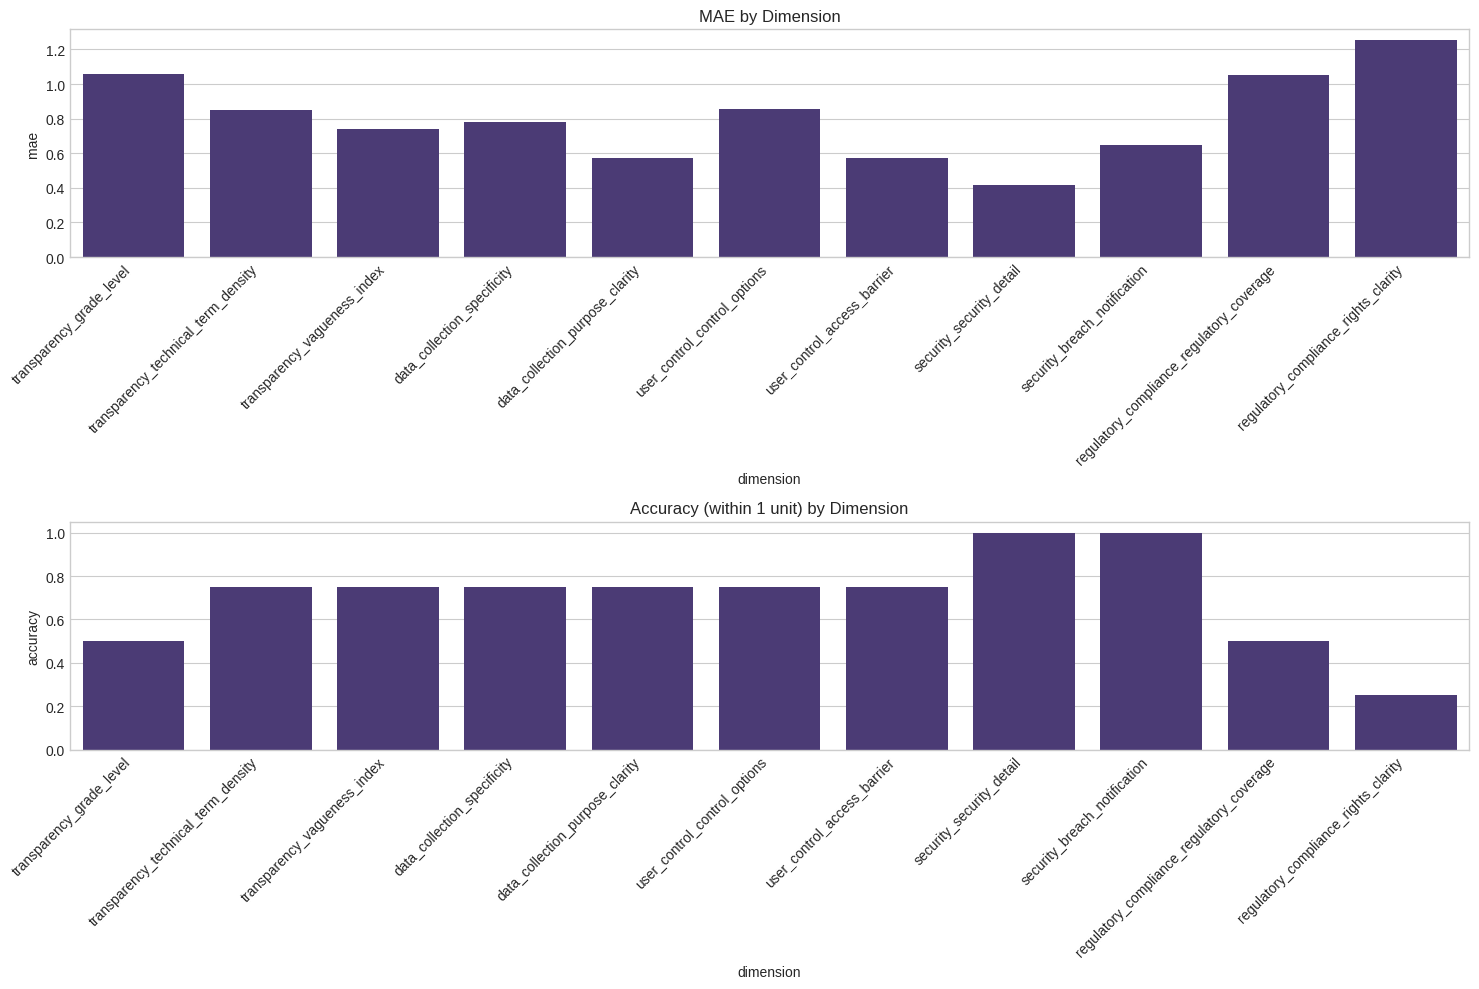

Creating visualizations...
Saved privacy_model_performance.png
Saved privacy_model_radar.png
Saved privacy_model_normalized_mae.png
Saved privacy_model_categories.png
Saved privacy_model_dashboard.png
Visualizations complete.
Main function completed.


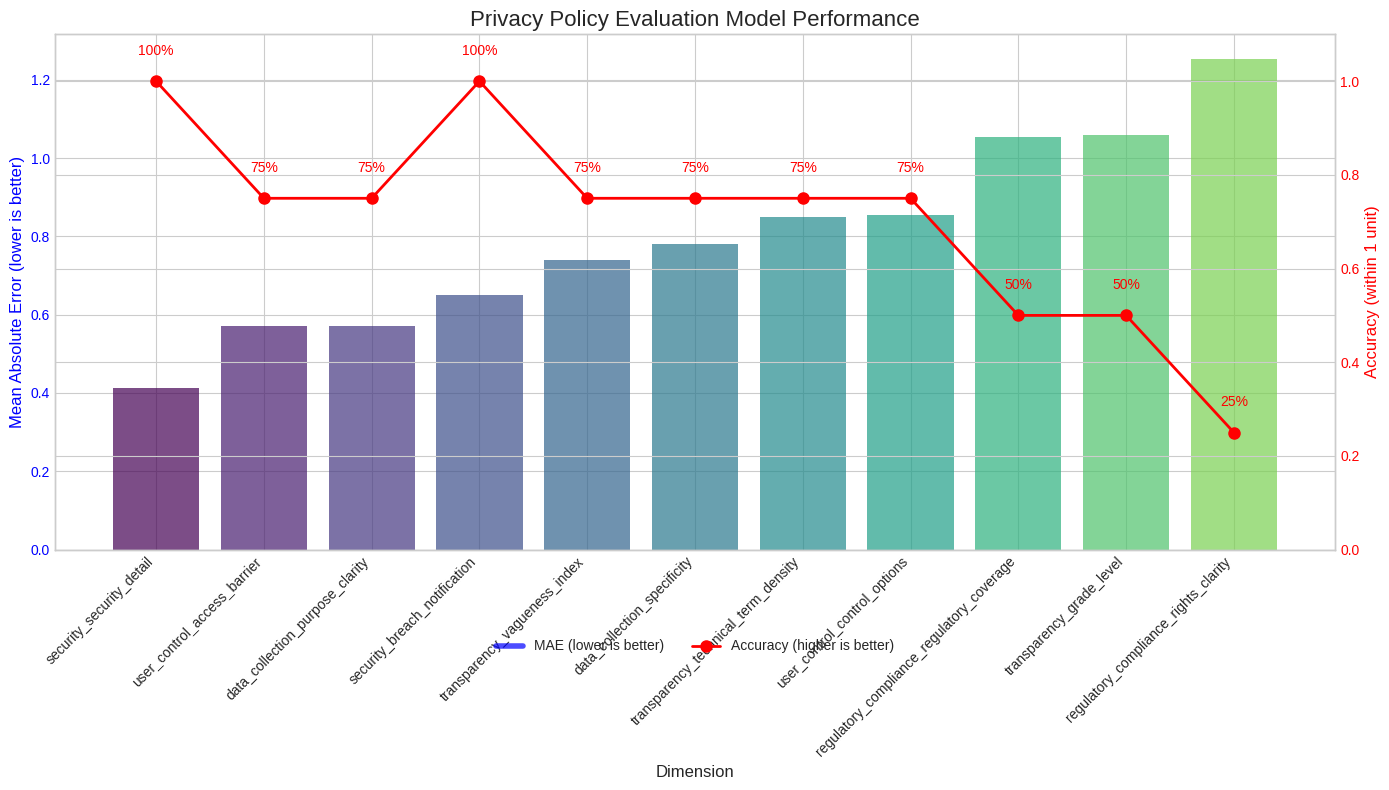

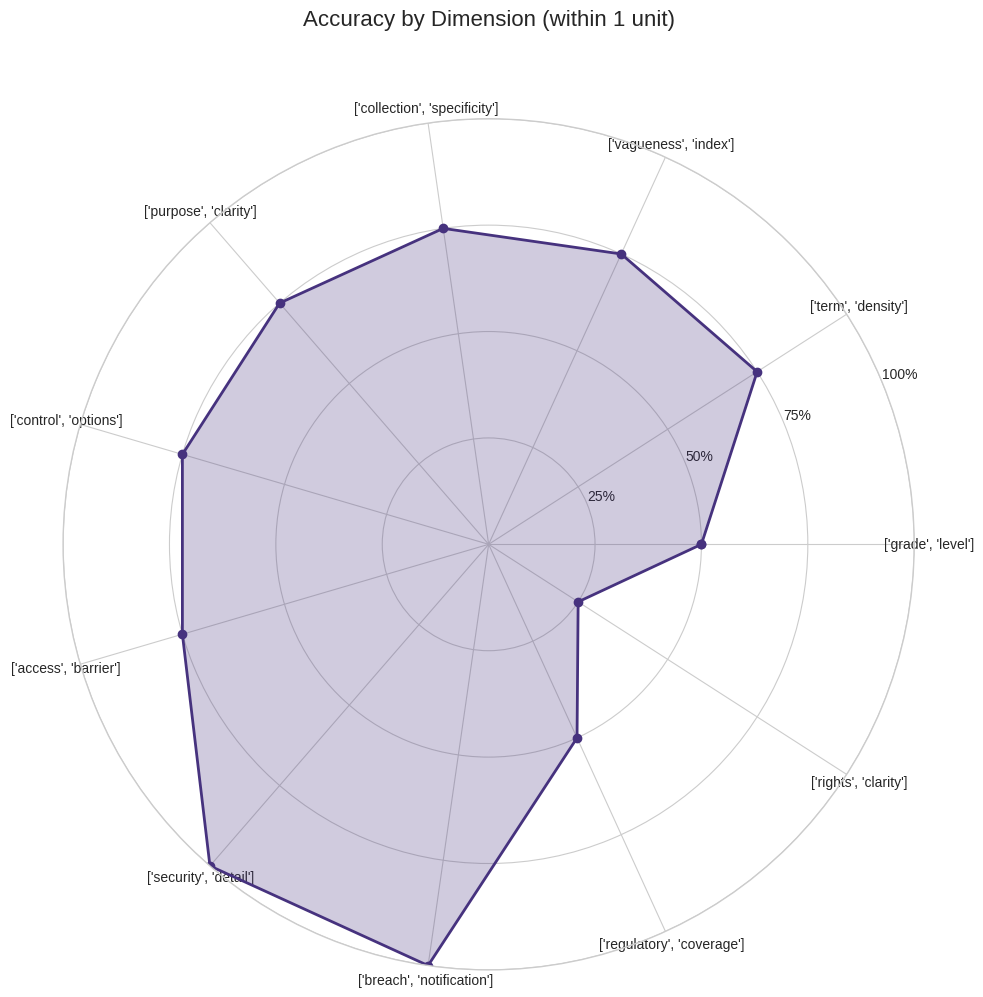

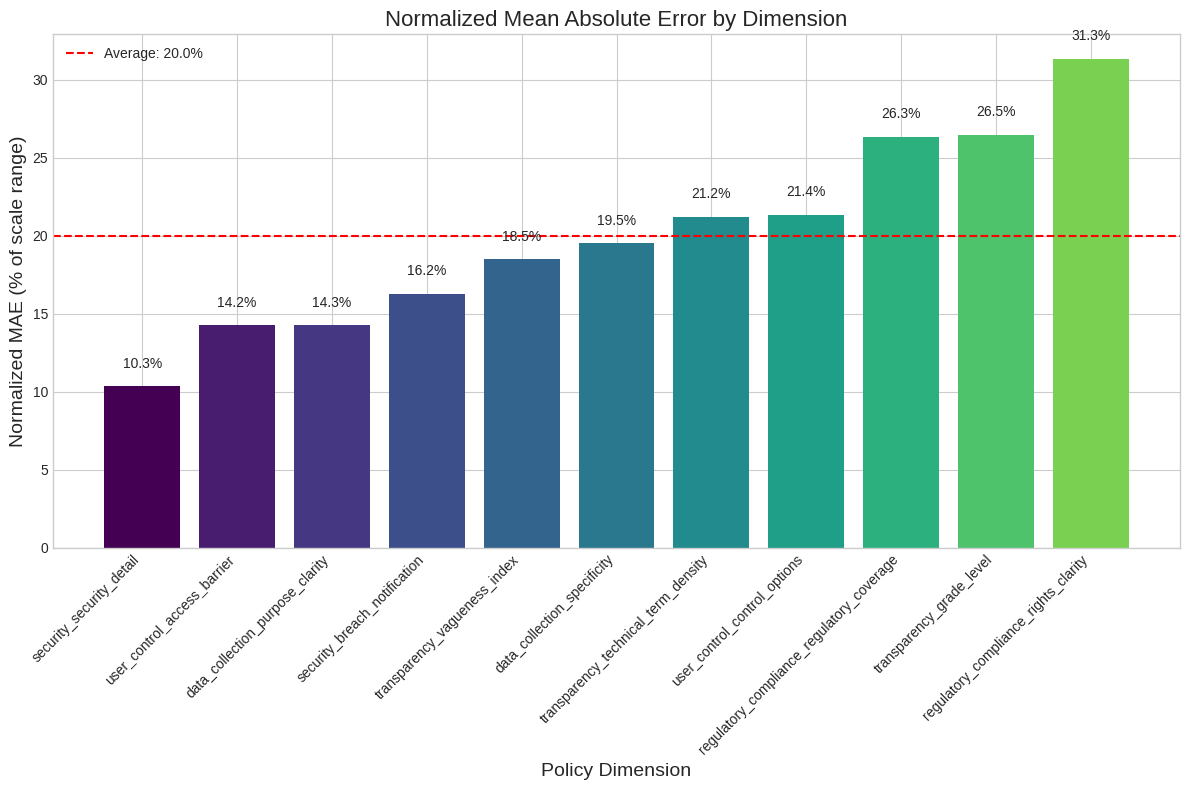

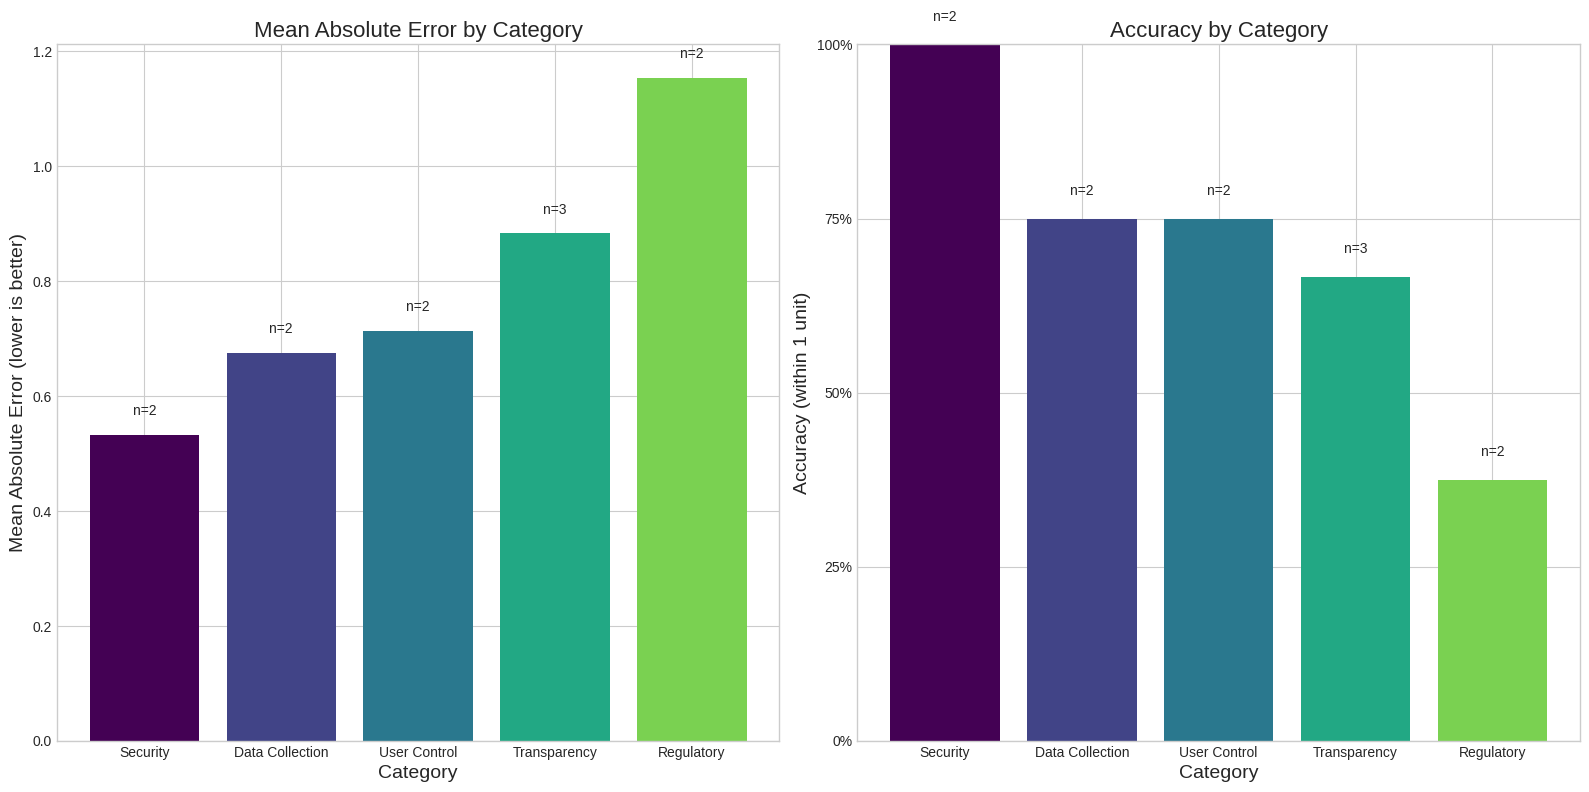

<Figure size 2000x1200 with 0 Axes>

In [ ]:
def main():
    """Main function to load data, train models, and evaluate results"""
    print("Loading datasets...")
    try:
        try:

            training_df = pd.read_csv('Dataset_Train.csv')

            test_df = pd.read_csv('Dataset_Test.csv')
            print("Loaded datasets from local files.")
        except Exception as e:
            print(f"Could not load from local files: {e}")

            from google.colab import files

            print("Please upload the training dataset (Flattened_Policy_Dataset.csv):")
            uploaded = files.upload()
            training_df = pd.read_csv(next(iter(uploaded)))

            print("Please upload the test dataset (Dataset_Test.csv):")
            uploaded = files.upload()
            test_df = pd.read_csv(next(iter(uploaded)))
            print("Loaded datasets from uploads.")

        print(f"Training dataset shape: {training_df.shape}")
        print(f"Test dataset shape: {test_df.shape}")
    except Exception as e:
        print(f"Error loading datasets: {e}")
        print("Please ensure both CSV files are uploaded to Colab.")
        return


    dimension_cols = [
        'transparency_grade_level',
        'transparency_technical_term_density',
        'transparency_vagueness_index',
        'data_collection_specificity',
        'data_collection_purpose_clarity',
        'user_control_control_options',
        'user_control_access_barrier',
        'security_security_detail',
        'security_breach_notification',
        'regulatory_compliance_regulatory_coverage',
        'regulatory_compliance_rights_clarity'
    ]


    train_existing_cols = [col for col in dimension_cols if col in training_df.columns]
    test_existing_cols = [col for col in dimension_cols if col in test_df.columns]
    common_cols = [col for col in train_existing_cols if col in test_existing_cols]

    print(f"Found {len(common_cols)} common dimension columns for training and testing:")
    for col in common_cols:
        print(f"- {col}")
        print(f"  Train - Min: {training_df[col].min()}, Max: {training_df[col].max()}, Mean: {training_df[col].mean():.2f}")
        print(f"  Test  - Min: {test_df[col].min()}, Max: {test_df[col].max()}, Mean: {test_df[col].mean():.2f}")


    results_dict = {
        'dimension': [],
        'mae': [],
        'accuracy': []
    }

    print("\n=== Training and Evaluating Models ===")

    for col in common_cols:
        print(f"\nTraining model for: {col}")


        extractor = PrivacyPolicyRuleExtractor()


        print("  Extracting features...")
        train_features = extractor.fit_transform(training_df[['policy_text']])
        test_features = extractor.transform(test_df[['policy_text']])


        try:
            print("  Adding embeddings...")
            train_embeddings = extract_embeddings(training_df['policy_text'].tolist())
            test_embeddings = extract_embeddings(test_df['policy_text'].tolist())

            X_train = pd.concat([train_features, train_embeddings], axis=1)
            X_test = pd.concat([test_features, test_embeddings], axis=1)
        except Exception as e:
            print(f"  Error adding embeddings: {e}")
            X_train = train_features
            X_test = test_features

        print(f"  Feature matrix shape: {X_train.shape}")


        missing_cols = set(X_train.columns) - set(X_test.columns)
        for c in missing_cols:
            X_test[c] = 0
        X_test = X_test[X_train.columns]


        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Train model
        print("  Training model...")
        model = ElasticNet(alpha=0.5, l1_ratio=0.7, max_iter=10000, random_state=42)
        model.fit(X_train_scaled, training_df[col])

        # Evaluate on test Data
        print("  Evaluating model...")
        y_test = test_df[col].values
        y_pred = model.predict(X_test_scaled)

        # Calculate metrics
        mae = mean_absolute_error(y_test, y_pred)
        accuracy = np.mean(np.abs(y_test - y_pred) <= 1.0)

        importance = pd.Series(np.abs(model.coef_), index=X_train.columns)
        top_features = importance.sort_values(ascending=False).head(5)

        print(f"  MAE: {mae:.4f}")
        print(f"  Accuracy (within 1 unit): {accuracy:.4f}")
        print("  Top 5 important features:")
        for feat, imp in top_features.items():
            print(f"    {feat}: {imp:.4f}")

        results_dict['dimension'].append(col)
        results_dict['mae'].append(mae)
        results_dict['accuracy'].append(accuracy)


    results_df = pd.DataFrame(results_dict)

    print("\n=== Summary of Results ===")
    print(results_df)

    # Overall performance
    print(f"\nOverall Mean MAE: {results_df['mae'].mean():.4f}")
    print(f"Overall Mean Accuracy (within 1 unit): {results_df['accuracy'].mean():.4f}")

    # Best and worst dimensions
    best_dim_mae = results_df.loc[results_df['mae'].idxmin(), 'dimension']
    worst_dim_mae = results_df.loc[results_df['mae'].idxmax(), 'dimension']

    print(f"\nBest performing dimension (MAE): {best_dim_mae}")
    print(f"Worst performing dimension (MAE): {worst_dim_mae}")


    try:
        plt.figure(figsize=(15, 10))

        # Plot MAE
        plt.subplot(2, 1, 1)
        sns.barplot(x='dimension', y='mae', data=results_df)
        plt.title('MAE by Dimension')
        plt.xticks(rotation=45, ha='right')

        # Plot Accuracy
        plt.subplot(2, 1, 2)
        sns.barplot(x='dimension', y='accuracy', data=results_df)
        plt.title('Accuracy (within 1 unit) by Dimension')
        plt.xticks(rotation=45, ha='right')

        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Error plotting results: {e}")

    return results_df


if __name__ == "__main__":
    results = main()
    visualizations = visualize_results_wrapper(results)
    print("Main function completed.")